# Getting There — transform-system sandbox

Stand-in for the eventual client: load a scenario, submit turns (optionally with orders), watch the world evolve. The `sim` package is the pure engine; `viz` is notebook-only rendering.

**Universal decay:** each turn, a location's next contents are *exactly* what its transforms produce — anything not re-emitted is gone. Storage is therefore itself a transform (`air → air` free, `food + energy → food` powered). Death is emergent: an unfed person runs no survival transform and simply isn't there next turn.

Each turn is `run_turn(world, scenario, orders) -> (world', replay)` — the shape the client/server API will take.

In [6]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))  # repo root, so `import sim` works

import matplotlib.pyplot as plt

from sim import load_scenario, initial_world, run_turn, scenario_from_dict, SpendNudges
import viz

SCENARIO = Path.cwd().parent / "scenarios_data" / "sample-world.json"

## Initial state

Two locations: `greenhouse` feeds `habitat`. Node labels show non-zero resources.

tick 0
  greenhouse: plant:8, energy:4
      priority: farming > survival > atmosphere > growth > food_storage > plant_storage > photosynthesis > air_storage
  habitat: person:2, food:4, energy:2, air:4
      priority: farming > survival > atmosphere > growth > food_storage > plant_storage > photosynthesis > air_storage
  TOTALS: person:2, food:4, plant:8, energy:6, air:4


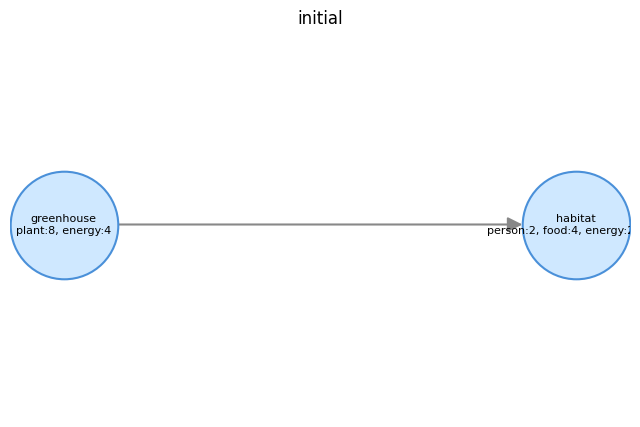

In [7]:
scenario = load_scenario(SCENARIO)
world = initial_world(scenario, seed=0)

print(viz.summarize(world, scenario))
viz.draw_world(world, scenario, title="initial")
plt.show()

## One turn

The replay lists what fired, in evaluation order.

In [8]:
scenario

Scenario(name='simple-world', resources=['person', 'food', 'plant', 'energy', 'air'], resource_index={'person': 0, 'food': 1, 'plant': 2, 'energy': 3, 'air': 4}, transform_names=['farming', 'survival', 'atmosphere', 'growth', 'food_storage', 'plant_storage', 'photosynthesis', 'air_storage'], need=array([[1, 0, 1, 0, 0],
       [1, 1, 0, 0, 1],
       [0, 0, 1, 1, 0],
       [0, 0, 1, 1, 0],
       [0, 1, 0, 1, 0],
       [0, 0, 1, 1, 0],
       [0, 0, 1, 0, 0],
       [0, 0, 0, 0, 1]]), emit=array([[1, 2, 0, 0, 0],
       [1, 0, 0, 0, 0],
       [0, 0, 1, 0, 1],
       [0, 0, 2, 0, 0],
       [0, 1, 0, 0, 0],
       [0, 0, 1, 0, 0],
       [0, 0, 1, 1, 0],
       [0, 0, 0, 0, 1]]), actions=[[], [], [], [], [], [], [], []], input_sets=[('local', 'nearby'), ('local', 'nearby'), ('local', 'nearby'), ('local', 'nearby'), ('local', 'nearby'), ('local', 'nearby'), ('local', 'nearby'), ('local', 'nearby')], location_ids=['greenhouse', 'habitat'], location_index={'greenhouse': 0, 'habitat': 1}

T (habitat): farming: food,person,food,person,person -> food,plant,person,person,person
T (habitat): atmosphere: person,person,food,food,person -> person,person,food,person,food
T (habitat): air_storage: person,person,person,person,food -> person,person,person,person,food
   habitat: farming x2
   habitat: atmosphere x6
   habitat: air_storage x4

tick 1
  greenhouse: (empty)
      priority: farming > survival > atmosphere > growth > food_storage > plant_storage > photosynthesis > air_storage
  habitat: person:2, food:4, plant:6, air:10
      priority: farming > survival > atmosphere > growth > food_storage > plant_storage > photosynthesis > air_storage
  TOTALS: person:2, food:4, plant:6, air:10


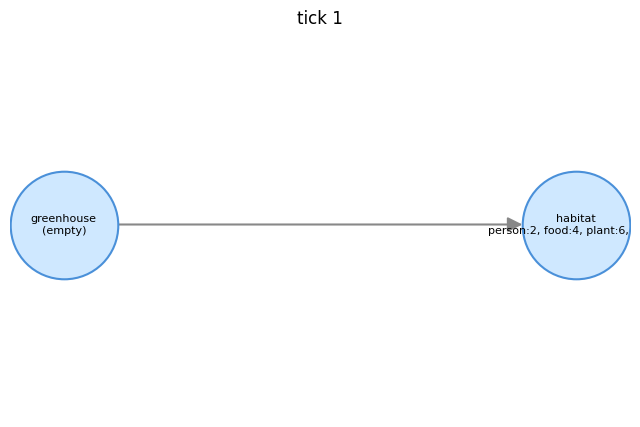

In [5]:
world, replay = run_turn(world, scenario)

for e in replay.events:
    print(f"{e.location_id:>10}: {e.transform} x{e.count}")
print()
print(viz.summarize(world, scenario))
viz.draw_world(world, scenario)
plt.show()

## Six turns, default priorities

Watch the DAG evolve. Because storage is a transform, whatever isn't actively re-emitted drains away — keep an eye on which resources hold and which decay.

In [ ]:
world = initial_world(scenario, seed=0)
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax in axes.flat:
    viz.draw_world(world, scenario, ax=ax)
    world, rep = run_turn(world, scenario)
plt.tight_layout()
plt.show()

In [ ]:
rep

In [ ]:
scenario

## The one order: nudge a location's priorities

The entire MVP order vocabulary is `SpendNudges(location, {transform: delta})` — spend nudges on **signed priority deltas**. Priority is a *score*, not a fixed slot list: a positive delta pushes a transform toward the front, a negative one back, and transforms contend for a shared pool so the resulting order decides who wins.

Two properties matter. Deltas **superpose** — several sources nudging the same transform just sum, so there is no arbitration or tiebreak. And a nudge **persists** by editing the score *once*: later turns keep the new order with no fresh order, and the delta is never re-applied. Below, `photosynthesis +2` and `growth +1` lift both to the front of the greenhouse (the +2/+1 keeps `photosynthesis` ahead of `growth`), changing what it does with its plants and energy. The `priority:` line annotates each nudged transform with its accumulated score.

In [ ]:
world = initial_world(scenario, seed=0)
order = SpendNudges("greenhouse", {"photosynthesis": +2, "growth": +1})

world, _ = run_turn(world, scenario, orders=[order])   # policy set here...
for _ in range(4):
    world, rep = run_turn(world, scenario)                # ...and persists, no new order

print(viz.summarize(world, scenario))
viz.draw_world(world, scenario, title="greenhouse: photosynthesis+growth first, after 5 turns")
plt.show()

In [ ]:
world

## Death is emergent

Under universal decay we no longer need a special rule for starvation. Give 5 people only 2 food: survival can re-emit just 2 of them, and the other 3 are absent next turn. This is the behavior the old persistence model couldn't produce.

In [ ]:
starve = scenario_from_dict({
    "resources": ["person", "food", "air"],
    "transforms": [
        {"name": "survival", "inputs": {"person": 1, "food": 1, "air": 1}, "outputs": {"person": 1}},
        {"name": "air_storage", "inputs": {"air": 1}, "outputs": {"air": 1}},
        {"name": "air_storage", "inputs": {"air": 1}, "outputs": {"air": 1}},
    ],
    "locations": [{"id": "hab", "resources": {"person": 5, "food": 2, "air": 8}, "destinations": []}],
    "evaluation_order": ["hab"],
})
w = initial_world(starve)
for t in range(4):
    print(viz.summarize(w, starve).splitlines()[1])  # habitat line
    w, _ = run_turn(w, starve)

In [ ]:
scenario

In [ ]:
world